# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

- 1. Choose an image from the Internet

  * Load or download an image from the Internet.

- 2. Perform the following operations on the image:
  * Read and display the original image
  * Scale (resize) the image (zoom in / zoom out)
  * Rotate the image by a given angle (30,45,60 (3 images))
  * Translate (shift) the image by some pixels
  * Apply an Affine Transformation
  * Zoom with Cropping
    * When zooming into an image, parts of the image may go beyond the frame.
    * Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
    * Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.
  * Save each transformed image with descriptive names

- 3. Advanced Image Transformation Tasks
  * Rotate around an arbitrary point
    * Write a function to rotate an image around a specific point (not the image center).

  * Combine Translation + Rotation
    * Apply a translation (shift) first, then rotate the image.
    * Reverse the order (rotate first, then translate) and compare the results.
    * Observe how the transformation order affects the final image.

  * Inverse Transformation
    * Given an image that has been rotated by 45° and translated 50px to the right,
    * Write a function to restore the original image by applying the inverse transformation.

  * Affine Transform for Data Augmentation
    * Generate 10 distinct augmented versions of the same image using combinations of affine transformations, including:
      * Rotation: randomly within ±10°
      * Scaling (Zoom): randomly zoom in or out by 10–20%
      * Translation: randomly shift the image by ±10 pixels along both x and y axes
      * (Optional) Combine multiple transformations in a single augmentation step to simulate real-world variations.
    * Save and display all augmented images.

  * Image Alignment (Image Registration)
    * Suppose you have two images of the same object but taken at slightly different angles.
    * Find the affine transformation matrix that aligns (registers) the two images.
    * Hint: Use the OpenCV function cv2.estimateAffinePartial2D().

- 4. Apply transformations to each color channel separately (R, G, B).
  * How do slight differences in rotation/scaling per channel affect the reconstructed RGB image?
  * Can this technique simulate color aberration seen in old cameras?

- 5.Report
  * Present the original image alongside all transformed images in a comparative layout.
  * Discuss how different transformations affect image geometry and potential implications for data augmentation or model training.

## 1. Choose an image from the Internet

Import Libs

In [6]:
import cv2 
import pandas as pd
import numpy as np
from cv2 import imwrite
from matplotlib import pyplot as plt    
from pylab import imread

Getting image

In [42]:
# Local
newImg = imread('the end.png')

# Online
# !gdown 1nlnqmg_br8e4UEDFnWeem6XqqD3Wgoos
# img_path = "/content/the end.png"
# newImg = imread(img_path)

## 2. Perform the following operations on the image:
  * Read and display the original image
  * Scale (resize) the image (zoom in / zoom out)
  * Rotate the image by a given angle (30,45,60 (3 images))
  * Translate (shift) the image by some pixels
  * Apply an Affine Transformation
  * Zoom with Cropping
    * When zooming into an image, parts of the image may go beyond the frame.
    * Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
    * Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.
  * Save each transformed image with descriptive names

Read and Display the original image

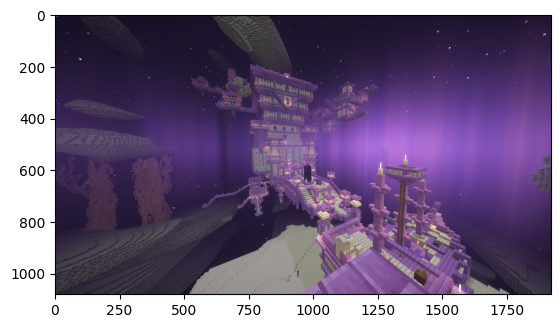

In [7]:
# read image
# local 
newImg = imread('the end.png')
# online
# newImg = imread(img_path)

# display image
plt.imshow(newImg)


Scale (resize) the image (zoom in / zoom out)

In [15]:
#Scale (resize) the image (zoom in / zoom out)
def resizeImage(image, widthScale, heightScale):
    scaledImgDim = (int(image.shape[1] * widthScale), int(image.shape[0] * heightScale))
    moddedImage = cv2.resize(image, scaledImgDim, interpolation = cv2.INTER_CUBIC)
    return moddedImage

# zoom in x2
zoomedInImg = resizeImage(newImg, 2, 2)

# zoom out x0.5
zoomedOutImg = resizeImage(newImg, 0.5, 0.5)

Rotate the image by a given angle (30,45,60 (3 images))

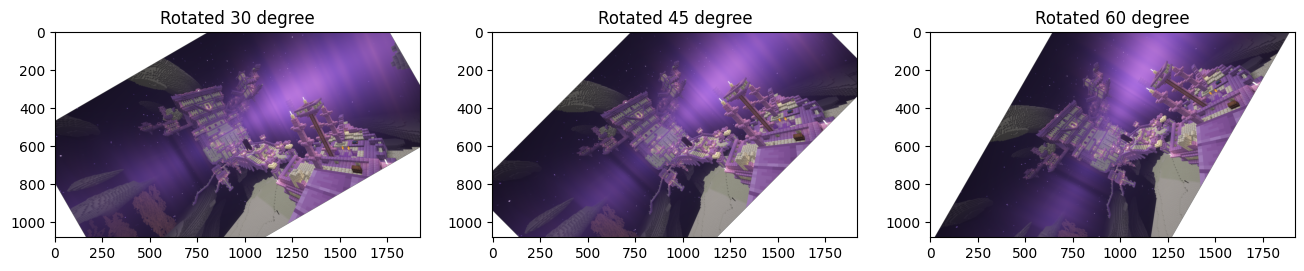

In [ ]:
#Rotate the image by a given angle (30,45,60 (3 images))
def rotateImage(image, angle, anchorPoint=None):
    if anchorPoint is None:
        imageRotatePoint = (image.shape[1]//2, image.shape[0]//2)
    else:
        imageRotatePoint = anchorPoint
    rotMat = cv2.getRotationMatrix2D(imageRotatePoint, angle, 1.0)
    rotatedImage = cv2.warpAffine(image, rotMat, (image.shape[1], image.shape[0])) # Width, Height :skull:
    return rotatedImage

# rotate 30 degree
rotatedImg30 = rotateImage(newImg, 30)
# rotate 45 degree
rotatedImg45 = rotateImage(newImg, 45)
# rotate 60 degree
rotatedImg60 = rotateImage(newImg, 60)

# Extra: rotate 60 degree with anchor point at top left corner
#rotatedImg60Anchored = rotateImage(newImg, 60, anchorPoint=(0, 0))

# Display 3 images
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.title("Rotated 30 degree")
plt.imshow(rotatedImg30)
plt.subplot(1,3,2)
plt.title("Rotated 45 degree")
plt.imshow(rotatedImg45)
plt.subplot(1,3,3)
plt.title("Rotated 60 degree")
plt.imshow(rotatedImg60)
plt.show()



Translate (shift) the image by some pixels

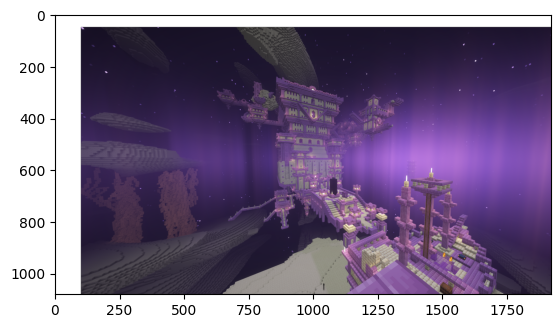

In [ ]:
# Translate (shift) the image by some pixels
def translateImage(image, x, y):
    transMat = np.float32([[1, 0, x], [0, 1, y]])
    translatedImage = cv2.warpAffine(image, transMat, (image.shape[1], image.shape[0]))
    return translatedImage

translatedImg = translateImage(newImg, 100, 50)

Apply an Affine Transformation

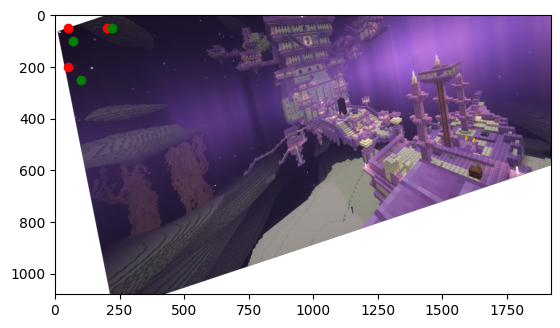

In [ ]:
# Apply an Affine Transformation
def affineTransform(image, originalPoints, transformedPoints):
    affineMat = cv2.getAffineTransform(np.float32(originalPoints), np.float32(transformedPoints))
    affineTransformedImage = cv2.warpAffine(image, affineMat, (image.shape[1], image.shape[0]))
    return affineTransformedImage

# test
originalPoints = [[50, 50], [200, 50], [50, 200]]
transformedPoints = [[70, 100], [220, 50], [100, 250]]
affinedImg = affineTransform(newImg, originalPoints, transformedPoints)
# Display the affine transformed image with points
plt.imshow(affinedImg)
# plt.title("Affine Transformed Image")
for pt in originalPoints:
    plt.plot(pt[0], pt[1], 'ro')  # original points in red
for pt in transformedPoints:
    plt.plot(pt[0], pt[1], 'go')  # transformed points in green
plt.show()


Zoom with Cropping
* When zooming into an image, parts of the image may go beyond the frame.
* Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
* Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027107451..1.1064633].


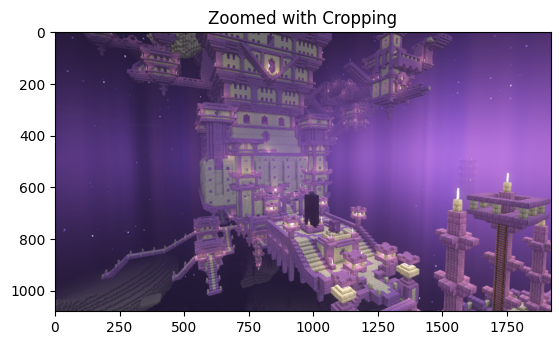

In [37]:
# Zoom with Cropping
#    * When zooming into an image, parts of the image may go beyond the frame.
#    * Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
#    * Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.

# Zoom with Cropping
def zoomWithCropping(image, zoomFactor):
    # Zoom the image
    zoomedImage = resizeImage(image, zoomFactor, zoomFactor)
    
    # Calculate cropping coordinates
    centerX, centerY = zoomedImage.shape[1] // 2, zoomedImage.shape[0] // 2
    halfWidth, halfHeight = image.shape[1] // 2, image.shape[0] // 2
    
    # Crop the central region
    croppedImage = zoomedImage[centerY - halfHeight:centerY + halfHeight,
                               centerX - halfWidth:centerX + halfWidth]
    
    return croppedImage
# Test zoom with cropping (zoom in by factor of 2)
zoomedCroppedImg = zoomWithCropping(newImg, 2)
plt.imshow(zoomedCroppedImg)
plt.title("Zoomed with Cropping")
plt.show()


## 2. Short report

### 2.1. Present the original image and all transformed images.

#### 2.1.1. Original Image/ Grayified Image

Text(0.5, 1.0, 'Grayified Image')

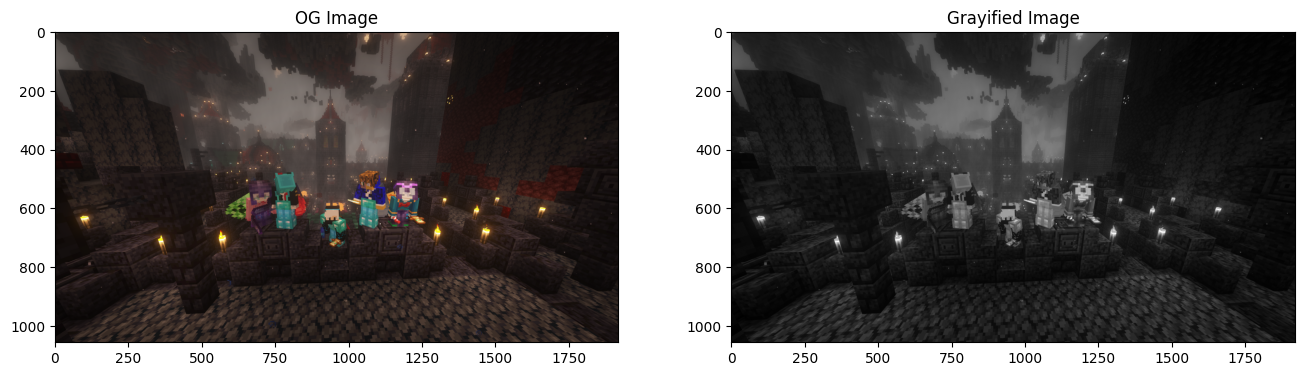

In [ ]:
# print images
plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.imshow(newImg)
plt.title("OG Image")


plt.subplot(1, 2, 2)
plt.imshow(newImg_grayified, cmap='gray')
plt.title("Grayified Image")

#### 2.1.2. Bit-plane Slicing Images

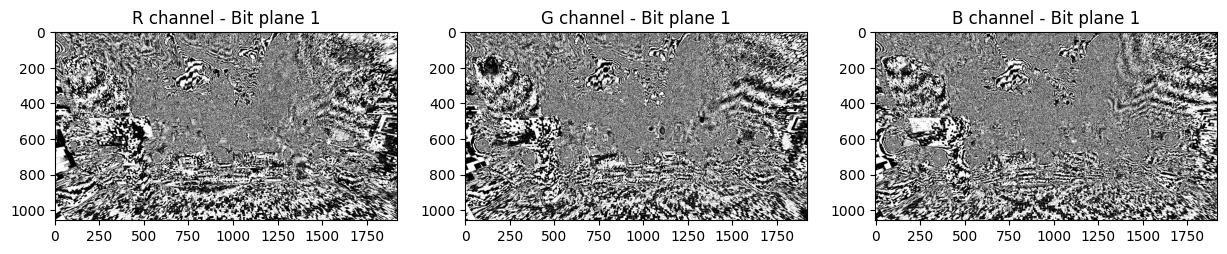

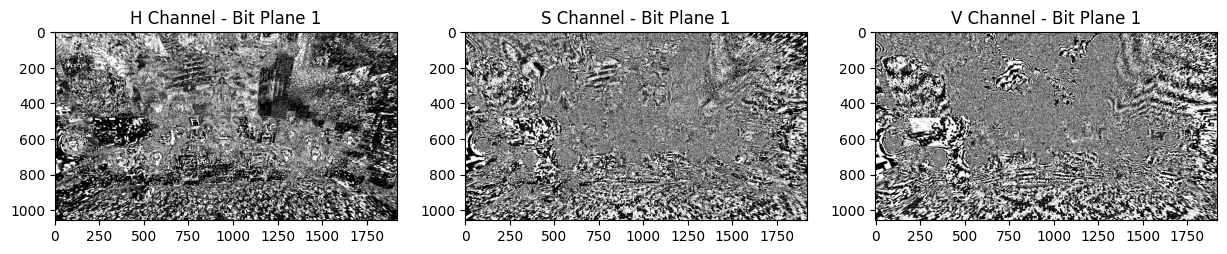

In [ ]:
# RGB
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(bit_plane_r, cmap='gray')
plt.title(f"R channel - Bit plane {BIT_INDEX}")

plt.subplot(1, 3, 2)
plt.imshow(bit_plane_g, cmap='gray')
plt.title(f"G channel - Bit plane {BIT_INDEX}")

plt.subplot(1, 3, 3)
plt.imshow(bit_plane_b, cmap='gray')
plt.title(f"B channel - Bit plane {BIT_INDEX}")
plt.show() 

# HSV
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.imshow(bit_plane_H, cmap='gray')
plt.title(f"H Channel - Bit Plane {BIT_INDEX}")

plt.subplot(1, 3, 2)
plt.imshow(bit_plane_S, cmap='gray')
plt.title(f"S Channel - Bit Plane {BIT_INDEX}")

plt.subplot(1, 3, 3)
plt.imshow(bit_plane_V, cmap='gray')
plt.title(f"V Channel - Bit Plane {BIT_INDEX}")
plt.show()

#### 2.1.4 Enhanced RGB images after enhancement using thresholds on the Value channel 

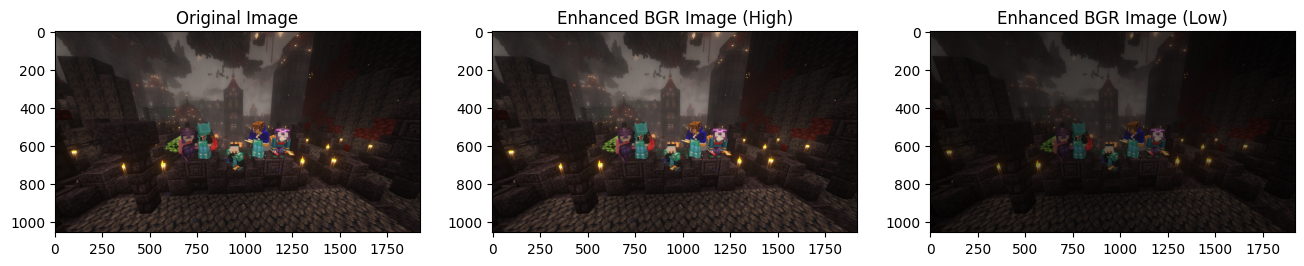

In [ ]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(newImg)
plt.title("Original Image")
plt.subplot(1, 3, 2)
plt.imshow(enhanced_bgrImg_high)
plt.title("Enhanced BGR Image (High)")
plt.subplot(1, 3, 3)
plt.imshow(enhanced_bgrImg_low)
plt.title("Enhanced BGR Image (Low)")
plt.show()

### 2.2. Write a short caption/description for each step

#### 2.2.1. Function to determine whether the image is color (RGB) or grayscale

def isGrayOrRGBImage(img) với input là ảnh và output sẽ là kết quả là ảnh gray (true) hay rgb (false)
* Do ảnh grayscaled thì sẽ có vector 2 thành phần (chỉ có height,width) nên ta sẽ kiểm tra chiều của ảnh được lấy qua img.shape: if len(img.shape) < 3 
    * Nếu thoả thì ảnh là grayscaled, trả về: 1, "gray image" 
    * Nếu không thì ảnh là rgb, trả về: 0, "RGB image"

#### 2.2.2. Function to print the minimum and maximum pixel values for each channels

def isGrayOrRGBImage(img) với input là ảnh và output sẽ là vector chứa min,max pixels 
* Ảnh grayscaled là vector có 2 thành phần, còn ảnh RGB có 3 thành phần nên ta chia 2 trường hợp: 
    * Nếu là ảnh grayscaled thì ta lấy luôn giá trị pixel lớn nhất và nhỏ nhất và trả về: 
    vector 2 thành phần(min_val, max_val)

    * Nếu là ảnh RGB thì ta xét từng channel r,g,b (0->2) và bỏ channel 3 vì đó là alpha channel. Khi đó ta thêm các phần tử min và max lần lượt của r,g,b vào min_vals, max_vals và tổng hợp lại trả về: 
    vector 6 thành phần (với 3 thành phần đầu là min(r,g,b) và 3 thành phần cuối là max(r,g,b))

#### 2.2.3. Display 1 bit-plane image for each of the R, G, B channels (3 images in total)

- B1: Chuyển ảnh dưới dạng uint8 để thực hiện bit-plane slicing 

In [ ]:
newImg_uint8 = (newImg * 255).astype(np.uint8)

- B2: Thực hiện bit-plane slicing 

In [ ]:
#Chọn bit plane bậc 1:
BIT_PLANE_VALUE = 2 

#Lấy bậc của bit plane:
BIT_INDEX = int(np.log2(BIT_PLANE_VALUE))

#Lấy ảnh kênh r,g,b của ảnh dưới dạng uint8:
r_channel = newImg_uint8[:, :, 2]
g_channel = newImg_uint8[:, :, 1]
b_channel = newImg_uint8[:, :, 0]

#Thực hiện bit-plane slicing vào ảnh kênh r,g,b
bit_plane_r = cv2.bitwise_and(r_channel, BIT_PLANE_VALUE)
bit_plane_g = cv2.bitwise_and(g_channel, BIT_PLANE_VALUE)
bit_plane_b = cv2.bitwise_and(b_channel, BIT_PLANE_VALUE)

- B3: Vẽ ảnh

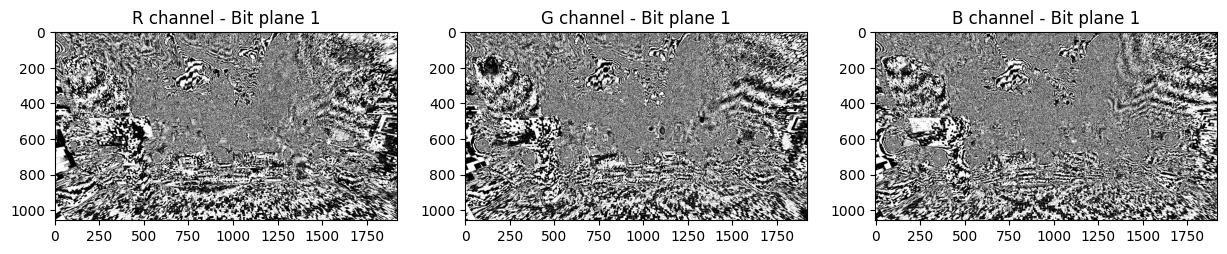

In [ ]:
#Giống Matlab
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(bit_plane_r, cmap='gray')
plt.title(f"R channel - Bit plane {BIT_INDEX}")

plt.subplot(1, 3, 2)
plt.imshow(bit_plane_g, cmap='gray')
plt.title(f"G channel - Bit plane {BIT_INDEX}")

plt.subplot(1, 3, 3)
plt.imshow(bit_plane_b, cmap='gray')
plt.title(f"B channel - Bit plane {BIT_INDEX}")
plt.show()

#### 2.2.4. Display 1 bit-plane image for each of the H, S, V channels (3 images in total)

- B1: Chuyển ảnh sang dạng uint8 và từ RGB thành HSV

In [ ]:
hsvImg = cv2.cvtColor(newImg_uint8, cv2.COLOR_BGR2HSV)

- B2: Thực hiện bit-plane slicing 

In [ ]:
#Chọn bit plane bậc 1:
BIT_PLANE_VALUE = 2

#Lấy bậc của bit plane:
BIT_INDEX = int(np.log2(BIT_PLANE_VALUE))

#Lấy ảnh kênh h,s,v của ảnh dưới dạng uint8:
h_hsvImg = hsvImg[:, :, 0]
s_hsvImg = hsvImg[:, :, 1]
v_hsvImg = hsvImg[:, :, 2]

#Thực hiện bit-plane slicing vào ảnh kênh h,s,v
bit_plane_H = cv2.bitwise_and(hsvImg[:, :, 0], BIT_PLANE_VALUE)
bit_plane_S = cv2.bitwise_and(hsvImg[:, :, 1], BIT_PLANE_VALUE)
bit_plane_V = cv2.bitwise_and(hsvImg[:, :, 2], BIT_PLANE_VALUE)

- B3: Vẽ ảnh 

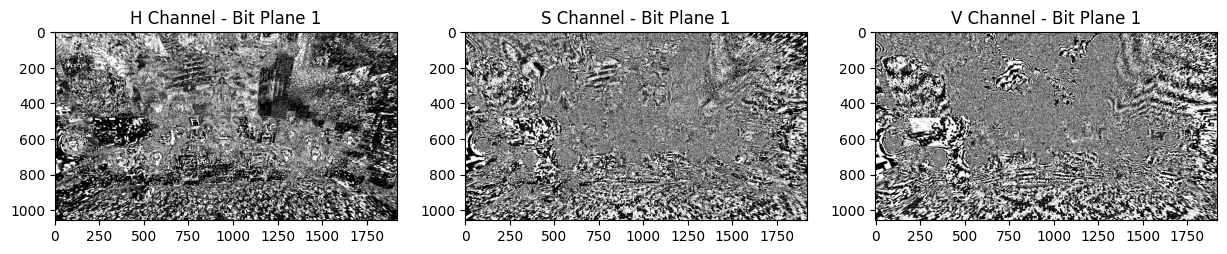

In [ ]:
#Giống Matlab
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.imshow(bit_plane_H, cmap='gray')
plt.title(f"H Channel - Bit Plane {BIT_INDEX}")

plt.subplot(1, 3, 2)
plt.imshow(bit_plane_S, cmap='gray')
plt.title(f"S Channel - Bit Plane {BIT_INDEX}")

plt.subplot(1, 3, 3)
plt.imshow(bit_plane_V, cmap='gray')
plt.title(f"V Channel - Bit Plane {BIT_INDEX}")
plt.show()

#### 2.2.5. Display histograms of the RGB channels and the HSV channels

- Kênh RGB

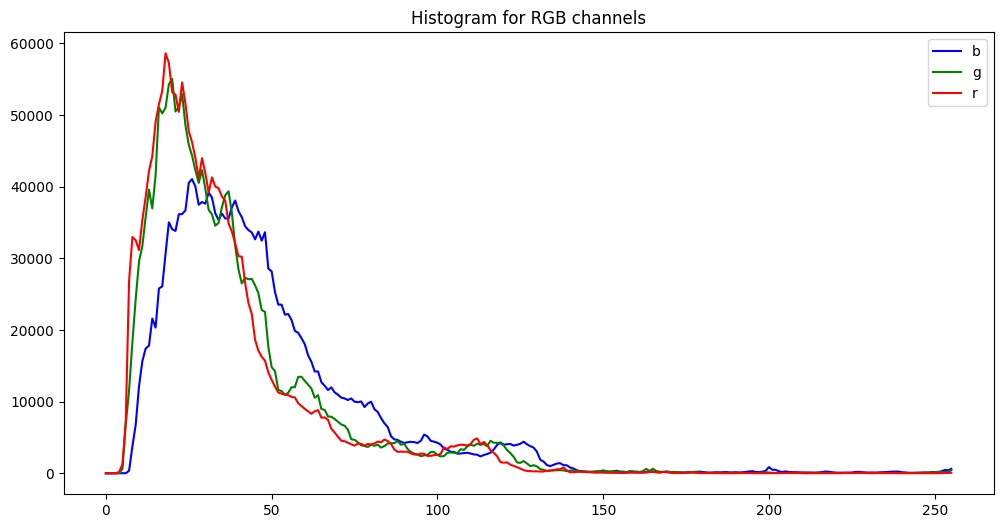

In [ ]:
# Đặt màu sắc cho histogram (trùng với màu của rgb)
color = ('b','g','r') 

plt.figure(figsize=(12, 6))
# Vẽ histogram cho các kênh màu RGB
for i, col in enumerate(color):
    #calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]]) → hist
    #Dùng newImg_uint8 vì nó đã ở dạng uint8 [0,255] thay vì newImg [0,1]
    histr = cv2.calcHist([newImg_uint8], [i], None, [256], [0, 256])
    plt.plot(histr, color=col)
    plt.legend(color)
plt.title("Histogram for RGB channels")
plt.show()


- Kênh HSV

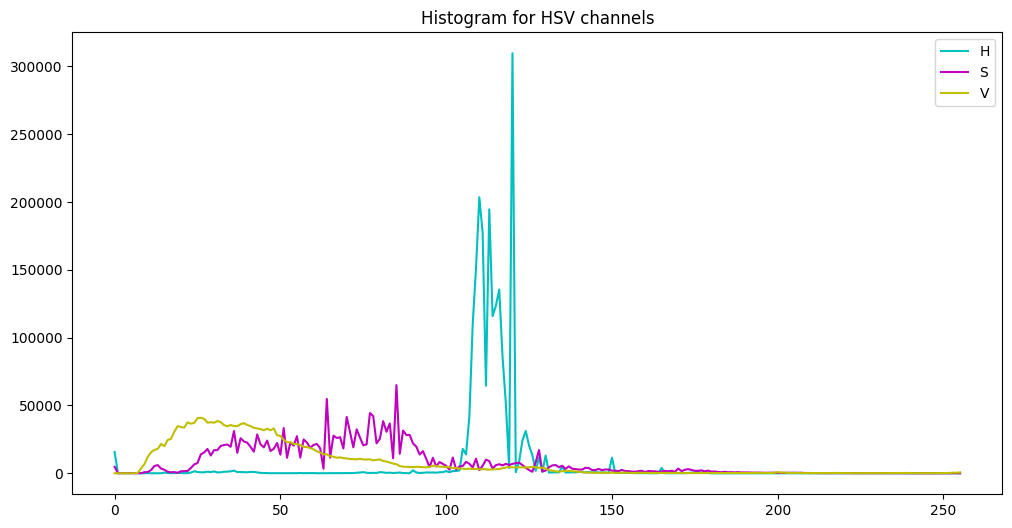

In [ ]:
# Đặt màu sắc cho histogram 
color = ('c','m','y')
names = ('H', 'S', 'V')
plt.figure(figsize=(12, 6))
lines = [] 
# Vẽ histogram cho các kênh màu HSV
for i, col in enumerate(color):
    # calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]]) → hist
    # Dùng hsvImg vì nó đã ở dạng uint8 [0,255]
    histr = cv2.calcHist([hsvImg], [i], None, [256], [0, 256])
    line, = plt.plot(histr, color=col)
    lines.append(line)

plt.legend(lines, names)
plt.title("Histogram for HSV channels")
plt.show()

#### 2.2.6. Enhancement using thresholds on the Value channel (V in HSV):

- Choose a low threshold and a high threshold


In [ ]:
# Lấy khoảng ngưỡng thấp và cao tầm 20% và 80% brightness
low_threshold = 50 # 50/255 ~ 20% brightness
high_threshold = 200  #200/255 ~ 80% brightness

new_hsvImg = cv2.cvtColor(newImg, cv2.COLOR_BGR2HSV)
# h, s, v 
h, s, v = cv2.split(new_hsvImg)

- For pixels below the low threshold → make them darker

In [ ]:
#Chuyển đổi ảnh thành khoảng [0,255]
v_low = v.copy().astype(np.float32)
#Kiểm tra các pixel thấp hơn ngưỡng
pixels_low = v_low < low_threshold
#Giảm độ sáng của các pixel thấp hơn ngưỡng
v_low[pixels_low] = v_low[pixels_low] * 0.5

- For pixels above the high threshold → make them brighter.

In [ ]:
#Chuyển đổi ảnh thành khoảng [0,255]
v_high = v.copy().astype(np.float32)
#Kiểm tra các pixel cao hơn ngưỡng
pixels_high = v_high > high_threshold
#Tăng độ sáng của các pixel cao hơn ngưỡng
v_high[pixels_high] = v_high[pixels_high] * 1.5